## CORE LIBRARIES

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.utils import resample
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## Load and Inspect dataset

In [2]:
#Load and Prepare data
loanApproval = pd.read_csv("Loan_Access.csv")

print(loanApproval.shape)
print(loanApproval['Loan_Approved'].value_counts(normalize=True))


(7500, 16)
Loan_Approved
Denied      0.568533
Approved    0.431467
Name: proportion, dtype: float64


# The dataset is made up of 7500 observations and 16 features and from the proportion of Approved and Denied loan applications the dataset is a balanced one

In [3]:
loanApproval.head()

,ID,Gender,Race,Age,Age_Group,Income,Credit_Score,Loan_Amount,Employment_Type,Education_Level,Citizenship_Status,Language_Proficiency,Disability_Status,Criminal_Record,Zip_Code_Group,Loan_Approved
0,415,Female,White,62,Over 60,90470,790,100269,Full-time,Bachelor's,Citizen,Fluent,No,No,Urban Professional,Approved
1,334,Male,White,49,25-60,106317,615,278731,Full-time,Bachelor's,Citizen,Fluent,No,No,Urban Professional,Approved
2,4658,Female,Hispanic,58,25-60,96596,698,414326,Full-time,Some College,Citizen,Fluent,Yes,No,Urban Professional,Approved
3,1794,Female,White,41,25-60,69501,840,414801,Part-time,Graduate,Citizen,Fluent,No,No,Urban Professional,Denied
4,9101,Male,White,32,25-60,128322,779,298557,Full-time,Some College,Citizen,Fluent,No,No,High-income Suburban,Approved


## Define Variable Groups 

In [4]:
target = "Loan_Approved"
protected_attributes = [
    "Gender",
    "Race",
    "Age_Group",
    "Disability_Status"
]

numerical_features = [
    "Income",
    "Credit_Score",
    "Loan_Amount",
    "Age"
]

categorical_features = [
    "Employment_Type",
    "Education_Level",
    "Citizenship_Status",
    "Language_Proficiency",
    "Criminal_Record",
    "Zip_Code_Group"
]

    

## TRAIN/TEST SPLIT

In [5]:
X = loanApproval.drop(columns=[target])
y = loanApproval[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)



## PREPROCESSING

In [6]:
# ONE-HOT ENCODE

X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


In [7]:
## Scale Numeric Features (for Logistic Regression)
scaler = StandardScaler()

X_train_encoded[numerical_features] = scaler.fit_transform(
    X_train_encoded[numerical_features]
)

X_test_encoded[numerical_features] = scaler.transform(
    X_test_encoded[numerical_features]
)


In [8]:
## Baseline Models

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier()
}

results = {}


In [9]:
for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)
    y_prob = model.predict_proba(X_test_encoded)[:, 1]

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    print(results)


C:\Users\efeto_bqwt3w7\anaconda3\Jayosowa\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic': {'accuracy': 0.628, 'roc_auc': 0.6742990025839253}}
{'Logistic': {'accuracy': 0.628, 'roc_auc': 0.6742990025839253}, 'RandomForest': {'accuracy': 0.6253333333333333, 'roc_auc': 0.6424383751144408}}
{'Logistic': {'accuracy': 0.628, 'roc_auc': 0.6742990025839253}, 'RandomForest': {'accuracy': 0.6253333333333333, 'roc_auc': 0.6424383751144408}, 'GradientBoosting': {'accuracy': 0.6195555555555555, 'roc_auc': 0.6616628110433213}}


## FAIRNESS METRICS FUNCTIONS

In [10]:
# Statistical Parity Difference
def statistical_parity_difference(y_pred, protected):
    groups = protected.unique()
    rates = {}

    for g in groups:
        rates[g] = y_pred[protected == g].mean()
    return max(rates.values()) - min(rates.values())

# Disparate Impact Ratio
def disparate_impact_ratio(y_pred, protected):
    groups = protected.unique()
    rates = []

    for g in groups:
        rates.append(y_pred[protected == g].mean())
    return min(rates) / max(rates)



## FAIRNESS EVALUATION

In [11]:
protected_test = X_test["Race"]

model = models["RandomForest"]
y_pred = model.predict(X_test_encoded)

# Define results containers
spd_results = {}
dir_results = {}
# Convert string predictions to numeric values
# Convert 'Approved' to 1 and anything else to 0
y_pred_numeric = np.array([1 if pred == 'Approved' else 0 for pred in y_pred])

# Caiculate metrics for each racial gr0up compared to others
for race in ["White","Black","Hispanic","Asian","Multiracial"]:
    # create binary indicator for current race(1) vs others(0)
    protected_binary = (protected_test == race).astype(int)



    # Calculate metrics
    spd_results[race] = statistical_parity_difference(y_pred_numeric, protected_binary)
    privileged = np.mean(y_pred_numeric[protected_binary == 0]).astype(float)
    unprivileged = np.mean(y_pred_numeric[protected_binary == 1]).astype(float)
    if unprivileged > 0:
        dir_results[race] = privileged / unprivileged
    else:
        dir_results[race] = float('inf') if privileged > 0 else 1.0

for race in ["White","Black","Hispanic","Asian","Multiracial"]:
    print(f"SPD ({race} vs Others):", spd_results[race])
    print(f"DIR ({race} vs Others):", dir_results[race])


SPD (White vs Others): 0.11911761794460612
DIR (White vs Others): 0.6899741076144225
SPD (Black vs Others): 0.17030285571099588
DIR (Black vs Others): 1.8993185889299957
SPD (Hispanic vs Others): 0.047029620405168004
DIR (Hispanic vs Others): 1.1578559432729987
SPD (Asian vs Others): 0.05457007447528778
DIR (Asian vs Others): 1.1909952606635072
SPD (Multiracial vs Others): 0.0999368736684289
DIR (Multiracial vs Others): 0.7701451905626135


# BOOTSTRAP CONFIDENT INTERVALS

In [12]:
def bootstrap_spd(y_pred, protected, n_iterations=1000):
    spd_values = []

    for _ in range(n_iterations):
        sample_idx = np.random.choice(len(y_pred), len(y_pred), replace=True)
        spd = statistical_parity_difference(
            y_pred[sample_idx],
            protected.iloc[sample_idx]
        )
        spd_values.append(spd)

    return np.percentile(spd_values, [2.5, 97.5])


# PROXY DISCRIMINATION TEST

## Remove Protected Attributes

In [13]:
X_train_no_prot = X_train.drop(columns=protected_attributes)
X_test_no_prot = X_test.drop(columns=protected_attributes)


## Re-encode and retrain

## encode target

In [14]:
loanApproval["Loan_Approved"] = loanApproval["Loan_Approved"].map({
    "Approved": 1,
    "Denied": 0
})


## encode protected attribute

In [15]:
loanApproval["Gender"] = loanApproval["Gender"].map({
    "Female": 0,
    "Male": 1
})

## remove Proxy features

In [17]:
proxy_features = [
    "Zip_Code_Group",
    "Race",
    "Citizenship_Status",
    "Language_Proficiency"
]

proxy_features = [c for c in proxy_features if c in loanApproval.columns]


## Features + Target

In [18]:
X = loanApproval.drop(
    columns=[
        "Loan_Approved",
        "Gender",
        "ID"
    ] + proxy_features
)

y = loanApproval["Loan_Approved"]


## Train Test Split

In [33]:
protected = loanApproval["Gender"]

X_train, X_test, y_train, y_test, p_train, p_test = train_test_split(
    X,
    y,
    protected,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Column types

In [20]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns


## RE-ENCODING

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols
        )
    ]
)

## Baseline Models

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

## Retrain models

In [28]:
from sklearn.pipeline import Pipeline
trained_models = {}

for model_name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    # Retrain model
    pipeline.fit(X_train, y_train)

    trained_models[model_name] = pipeline

    print(f"{model_name} retrained successfully.")

print("\nRe-encoding and retraining completed.")

Logistic Regression retrained successfully.
Random Forest retrained successfully.
Gradient Boosting retrained successfully.

Re-encoding and retraining completed.


## Fairness metrics

In [29]:
def statistical_parity_difference(y_pred, protected_group):

    # Female = 0
    # Male = 1

    group0 = y_pred[protected_group == 0]
    group1 = y_pred[protected_group == 1]

    p0 = np.mean(group0)
    p1 = np.mean(group1)

    return p0 - p1


def disparate_impact_ratio(y_pred, protected_group):

    group0 = y_pred[protected_group == 0]
    group1 = y_pred[protected_group == 1]

    p0 = np.mean(group0)
    p1 = np.mean(group1)

    if p0 == 0:
        return np.nan

    return p1 / p0


## Train + Evaluate models

In [35]:
results = []

for model_name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Calculate fairness metrics
    spd = statistical_parity_difference(
        y_pred,
        p_test.values
    )

    dir_ratio = disparate_impact_ratio(
        y_pred,
        p_test.values
    )

    results.append({
        "Model": model_name,
        "SPD": round(spd, 4),
        "DIR": round(dir_ratio, 4)
    })


## RESULTS TABLE

In [36]:
results_loanApproval = pd.DataFrame(results)

print("\n=== FAIRNESS RESULTS ===")
print(results_loanApproval)


=== FAIRNESS RESULTS ===
                 Model     SPD     DIR
0  Logistic Regression  0.0100  0.9695
1        Random Forest  0.0195  0.9423
2    Gradient Boosting  0.0073  0.9795


In [37]:
print("\n=== INTERPRETATION ===")

for _, row in results_loanApproval.iterrows():

    model = row["Model"]
    spd = row["SPD"]
    dir_ratio = row["DIR"]

    print(f"\n{model}")

    # SPD Interpretation
    if abs(spd) < 0.10:
        print(f"SPD = {spd} → Low disparity")
    else:
        print(f"SPD = {spd} → Potential disparity")

    # DIR Interpretation
    if dir_ratio >= 0.80:
        print(f"DIR = {dir_ratio} → Passes 80% rule")
    else:
        print(f"DIR = {dir_ratio} → Possible disparate impact")

    # Proxy bias conclusion
    if abs(spd) >= 0.10 or dir_ratio < 0.80:
        print("Proxy bias may still exist.")
    else:
        print("Bias reduced after retraining.")


=== INTERPRETATION ===

Logistic Regression
SPD = 0.01 → Low disparity
DIR = 0.9695 → Passes 80% rule
Bias reduced after retraining.

Random Forest
SPD = 0.0195 → Low disparity
DIR = 0.9423 → Passes 80% rule
Bias reduced after retraining.

Gradient Boosting
SPD = 0.0073 → Low disparity
DIR = 0.9795 → Passes 80% rule
Bias reduced after retraining.


## Random Forest for interpretability

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train model
rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Extract feature importance 

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names
encoded_features = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get importance scores
importance_scores = rf_pipeline.named_steps[
    "classifier"
].feature_importances_

# Create dataframe
feature_importance_loanApproval = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importance_scores
})

# Sort descending
feature_importance_loanApproval = feature_importance_loanApproval.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print(feature_importance_loanApproval.head(15))

                               Feature  Importance
18                   num__Credit_Score    0.238479
17                         num__Income    0.235482
19                    num__Loan_Amount    0.208125
16                            num__Age    0.161540
8      cat__Education_Level_Bachelor's    0.015563
10    cat__Education_Level_High School    0.014721
3       cat__Employment_Type_Full-time    0.014004
11   cat__Education_Level_Some College    0.013996
9        cat__Education_Level_Graduate    0.012469
5       cat__Employment_Type_Part-time    0.010349
0                 cat__Age_Group_25-60    0.010242
6   cat__Employment_Type_Self-employed    0.009354
4             cat__Employment_Type_Gig    0.008705
1               cat__Age_Group_Over 60    0.008571
13          cat__Disability_Status_Yes    0.007668


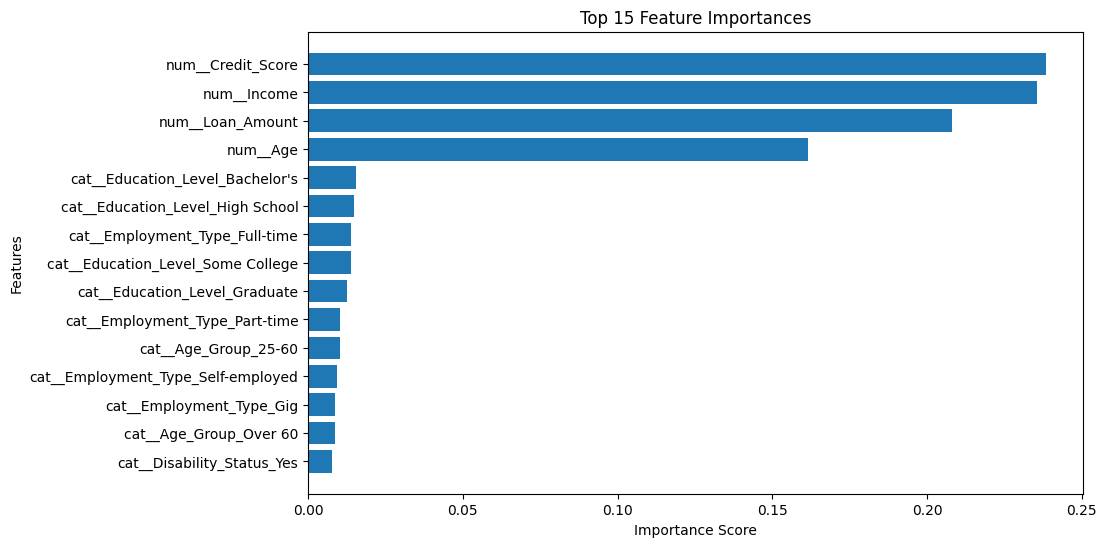

In [41]:
top_features = feature_importance_loanApproval.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

## Instal SHAP

In [42]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


## SHAP Analysis

In [46]:
import numpy as np

# Transform test data
X_test_transformed = rf_pipeline.named_steps[
    "preprocessor"
].transform(X_test)

# Check if sparse matrix
if hasattr(X_test_transformed, "toarray"):
    X_test_dense = X_test_transformed.toarray()
else:
    X_test_dense = np.array(X_test_transformed)

print(X_test_dense.shape)

(1500, 20)


In [49]:
import shap

# Get classifier
rf_model = rf_pipeline.named_steps["classifier"]

# Feature names
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# SHAP values
shap_values = explainer.shap_values(X_test_dense)

print("SHAP values generated.")

SHAP values generated.


## SHAP SUMMARY PLOT

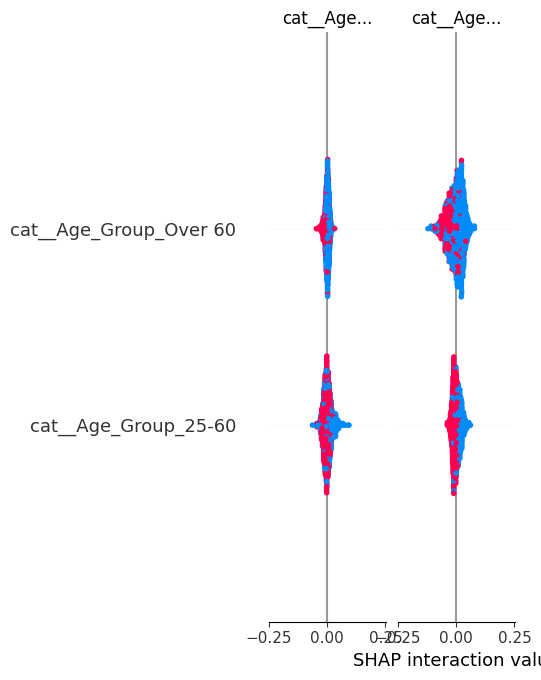

In [50]:
# For binary classification
if isinstance(shap_values, list):

    shap.summary_plot(
        shap_values[1],   # positive class
        X_test_dense,
        feature_names=feature_names
    )

else:

    shap.summary_plot(
        shap_values,
        X_test_dense,
        feature_names=feature_names
    )